# Quickstart

How to improve OT applications on AnnData.

In [1]:
import ggml_ot
import scanpy as sc
import pandas as pd

This tutorial uses the Myocardial Infarction dataset from Kuppe et. al, 2022. You can use the provided helper to fetch and cache it from [CELLxGENE](https://cellxgene.cziscience.com/collections/8191c283-0816-424b-9b61-c3e1d6258a77), or load your own AnnData object instead. We filter highly variable genes to speed up computations for the tutorial.

In [2]:
dataset_id = "c1f6034b-7973-45e1-85e7-16933d0550bc.h5ad"
adata = ggml_ot.data.load_cellxgene(dataset_id)

sc.pp.highly_variable_genes(adata, n_top_genes=5000, subset=True)

## Setup dataset `from_anndata`

To perform Supervised Optimal Transport, we set up a `TripletDataset` object based on the AnnData. This requires two parameters that identify relevant `obs` in the AnnData: 
- `patient_col` the patient/sample identifier
- `label_col` the corresponding patient groups/class labels whose relation we want to capture. 

The following columns (`.obs`) in the Myocardial Infarction AnnData object contain the information for each cell to which patient/sample it belongs (`patient_col`) and their corresponding disease state/label (`label_col`).

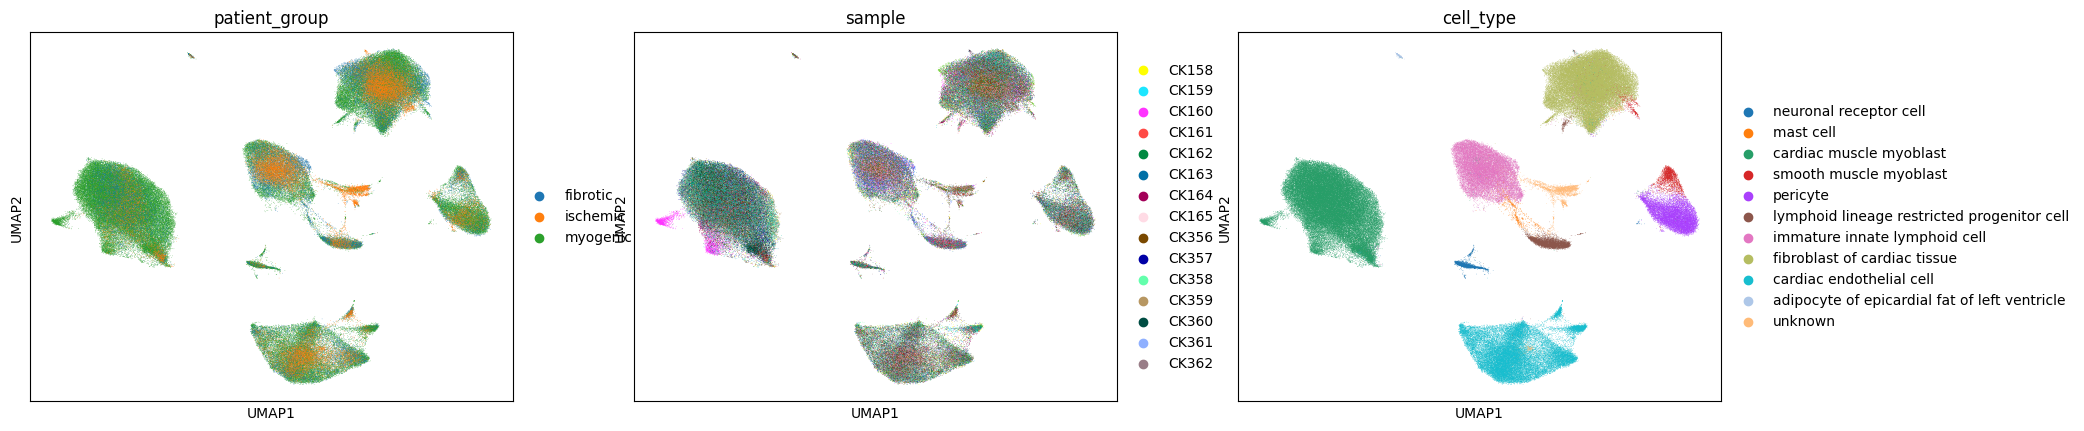

In [3]:
# Plot relevant .obs of Myocardial Infarction AnnData
sc.pl.umap(adata, color=["patient_group", "sample", "cell_type"])

# Setup dataset
dataset = ggml_ot.from_anndata(adata, patient_col="sample", label_col="patient_group")
dataset.normalize()

## Traditional OT on Single-cell data

A common analysis on single-cell data is to **investigate genetic differences between patient groups** like disease states. To capture these differences by Optimal Transport, each patient/sample is considered as a distribution of cells over the expressed genes. The cost of mapping the cells between two patient is then interpreted as a distance measure of their genetic differences.

To motivate Supervised Optimal Transport, we first compute the unsupervised OT distance between patients with common ground metric, the Euclidean distance and Cosine similarity. As an example application, we perform clustering and embedding of the patients.

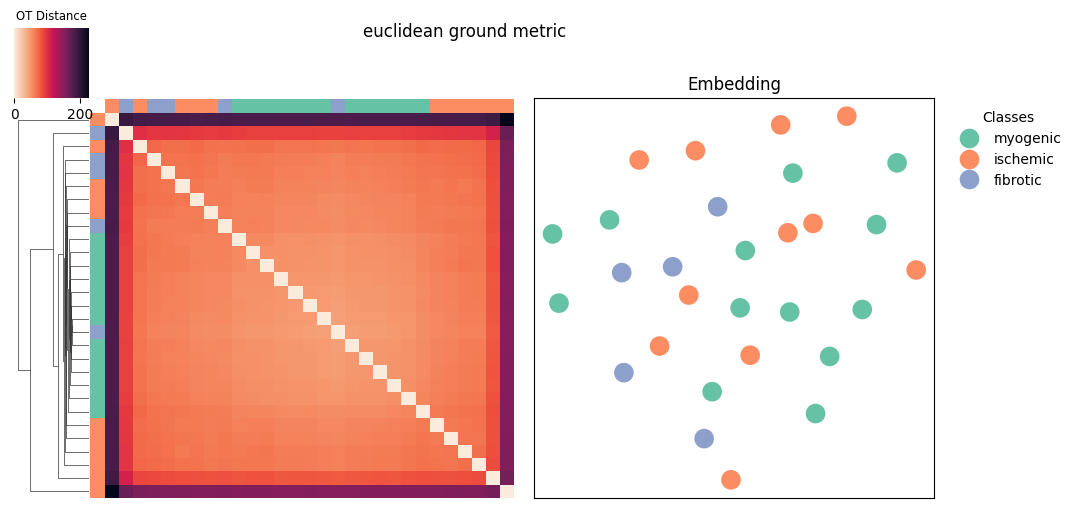

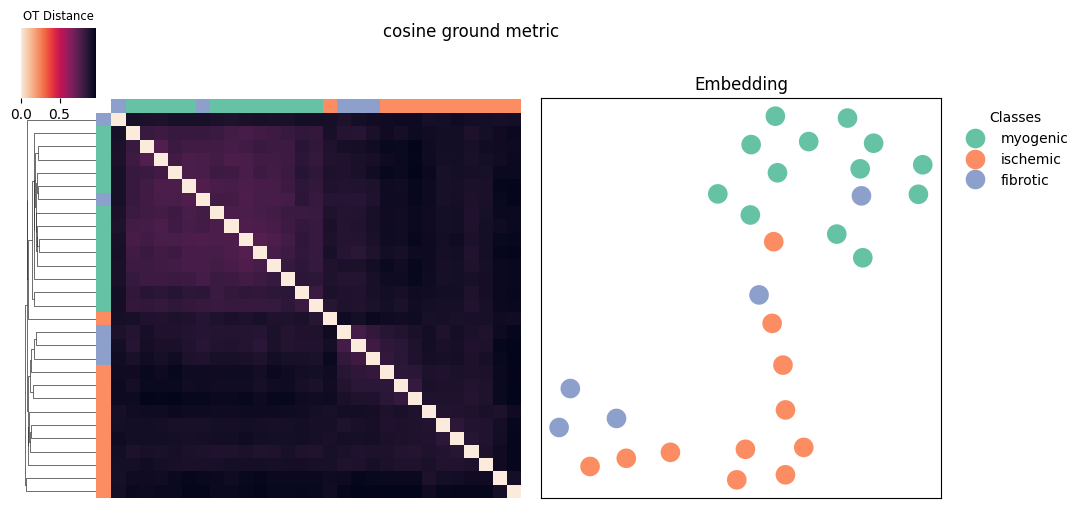

In [4]:
for fixed_ground_metric in ["euclidean", "cosine"]:
    _ = dataset.compute_OT(ground_metric=fixed_ground_metric)

We can see that Optimal Transport with Cosine ground metric captures some relation of the considered patient groups. However, unsupervised approaches cannot differentiate disease-related genetic differences from unrelated noise.

## Supervised OT with GGML `train()` 

Global Ground Metric Learning (GGML) learns ground metrics that capture class relations between distributions under OT. On single-cell data, it learns to capture the relation between patients w.r.t their disease state and thus, differentiates disease-related genetic changes from noise.

Let's train such a ground metric on the dataset object that we setup from the Myocardial Infarction AnnData. In this tutorial, we use the `train()` function with reduced latent dimensions (`n_comps = 2`) to better visualize the latent space in the next section.

Compute all OT distances after 20 iterations


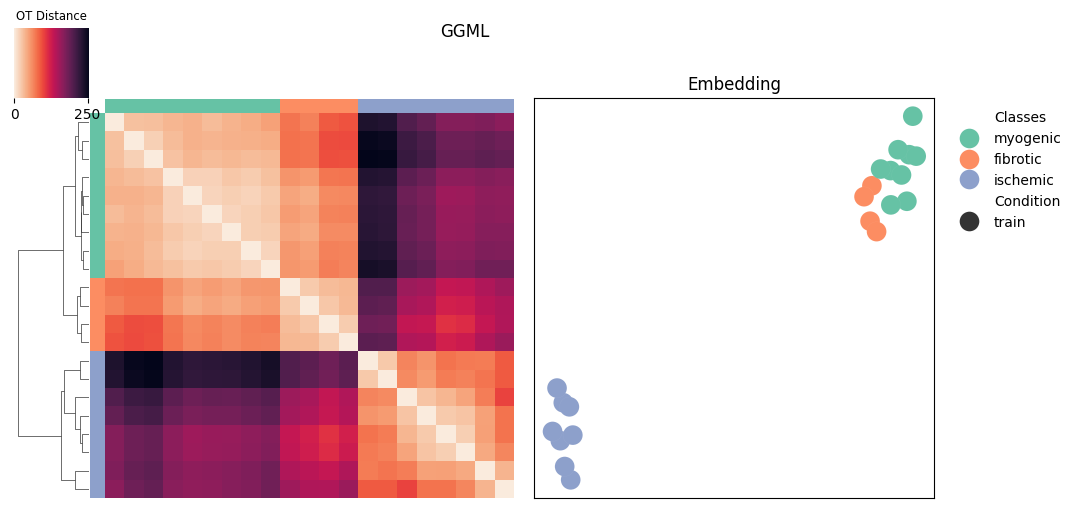

In [5]:
dataset.train(
    n_comps=2,
    train_size=0.75,
)

As shown, GGML learns a ground metric that separates the patients according to their disease states, which the euclidean and cosine ground metric did not capture.

## Learned Ground Metric and Latent Space 

By default, the `train()` method updates the AnnData object under `dataset.adata` with the learned ground metric. It is stored in the field `.varm["W_ggml"]`, which contains the components (or loadings) of the learned latent gene space. The embedding of the cells in this gene subspace is stored in `.obsm["X_ggml"]`.

In [6]:
adata = dataset.adata
adata

AnnData object with n_obs × n_vars = 191795 × 5000
    obs: 'sample', 'n_counts', 'n_genes', 'percent_mito', 'doublet_score', 'dissociation_score', 'cell_type_original', 'patient_region_id', 'donor_id', 'patient_group', 'major_labl', 'final_cluster', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'X_approximate_distribution', 'batch_condition', 'cell_type_original_colors', 'citation', 'default_embedding', 'schema_reference', 'schema_ver

The `.obsm["X_ggml"]` can be plotted with scanpy like other embeddings. Here, we plot the cardiac muscle myoblast cells to highlight the clear separation of the disease states (`patient_group`) in the latent space. It also shows that these differences generalize across patients (`sample`) with the respective disease state and are not due to batch effects.

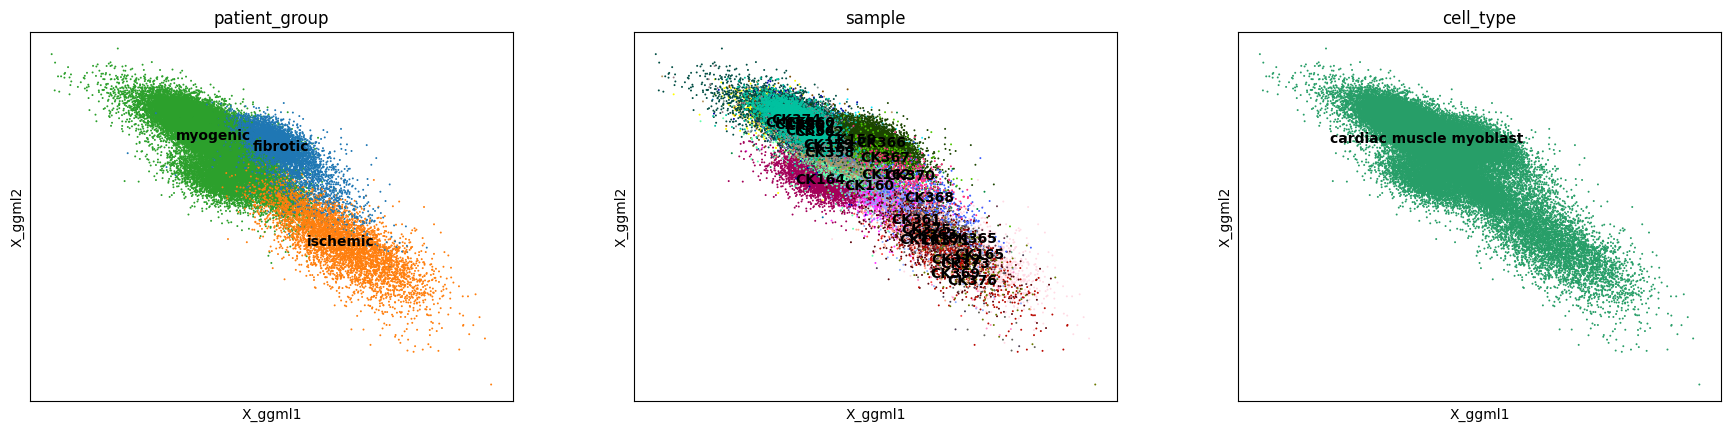

In [7]:
sc.pl.embedding(
    adata[adata.obs["cell_type"] == "cardiac muscle myoblast"],
    basis="X_ggml",
    color=["patient_group", "sample", "cell_type"],
    s=8,
    use_raw=False,
    legend_loc="on data",
)

## Evaluate Ground Metrics with `test()`

After training, we evaluate the learned ground metric on the corresponding test split with `test()` function. We compare it to the baseline of performing OT with the Euclidean distance and Cosine similarity as ground metric. 

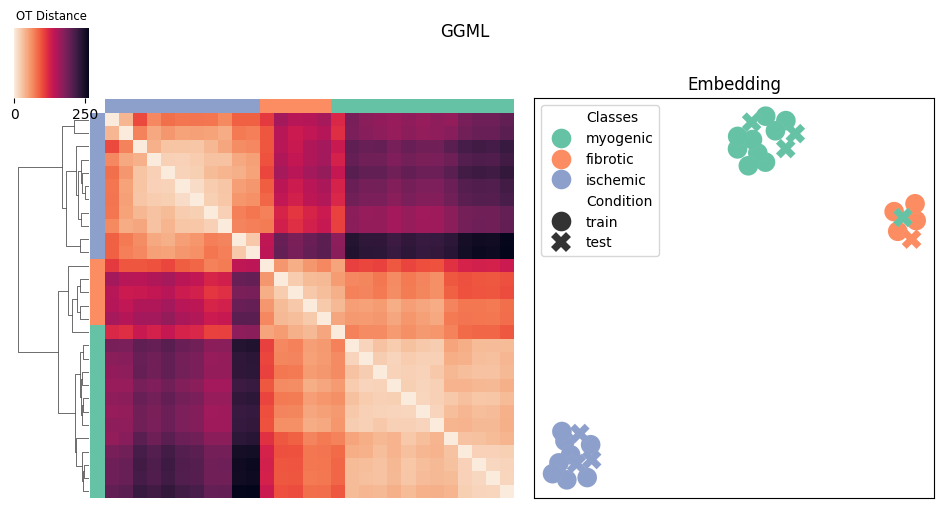

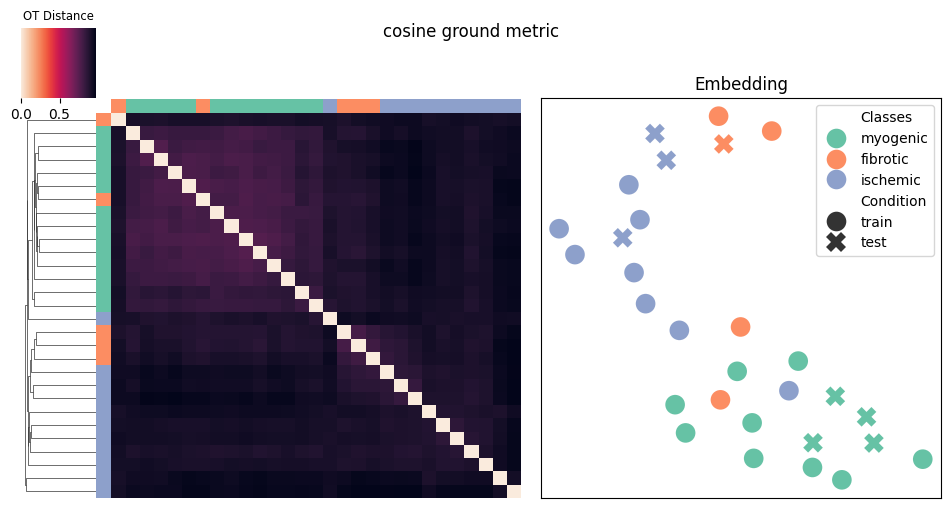

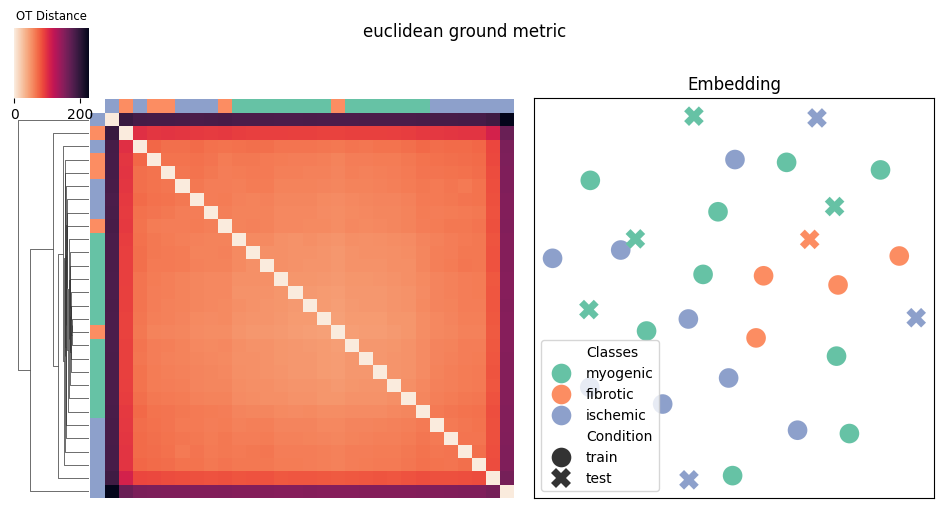

In [9]:
scores = {}
ground_metrics = {
    "GGML": dataset.map_A,
    "Cosine": "cosine",
    "Euclidean": "euclidean",
}

for name, metric in ground_metrics.items():
    scores[name] = dataset.test(
        ground_metric=metric,
        n_splits=1,
        test_size=0.25,
        knn_k=3,
        print_table=False,
    )

The classification (`knn`) and clustering results (`ari` etc.) shows that the learned metric from GGML also outperforms fixed ground metrics on unseen patients from the test set.

In [10]:
scores_df = pd.concat([scores[metric] for metric in scores], ignore_index=True)
ggml_ot.pl.table(scores_df.set_index(pd.Index(scores.keys(), name="Ground Metric")), style_performance=True)

## Cross-validation with `train_test()`
To evaluate generalizability, GGML can be cross-validated across train-test-splits with a single function call using <code><a href="../generated/ggml_ot.train_test.html">ggml_ot.train_test()</a></code>. The call combines <code><a href="../generated/ggml_ot.train.html">ggml_ot.train()</a></code> and <code><a href="../generated/ggml_ot.test.html">ggml_ot.test()</a></code> into one `n_splits`-fold loop and forwards all their parameters.

By default, it evaluates the following classification and clustering scores (configurable via the `scoring` parameter):
- k-NN classification accuracy (`"knn"`)
- Adjusted Rand Index (`"ari"`)

Additional clustering scores can be enabled: Normalized Mutual Information (`"mi"`) and Variation of Information (`"vi"`).

The output can be plotted for each split (by default `plot_split=True`) and outputted as a formatted table (by default `print_table=True`).

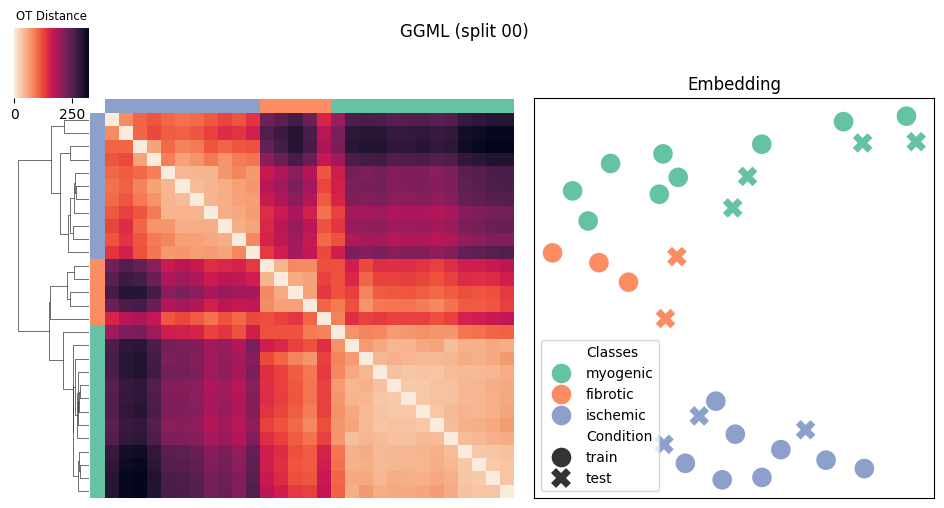

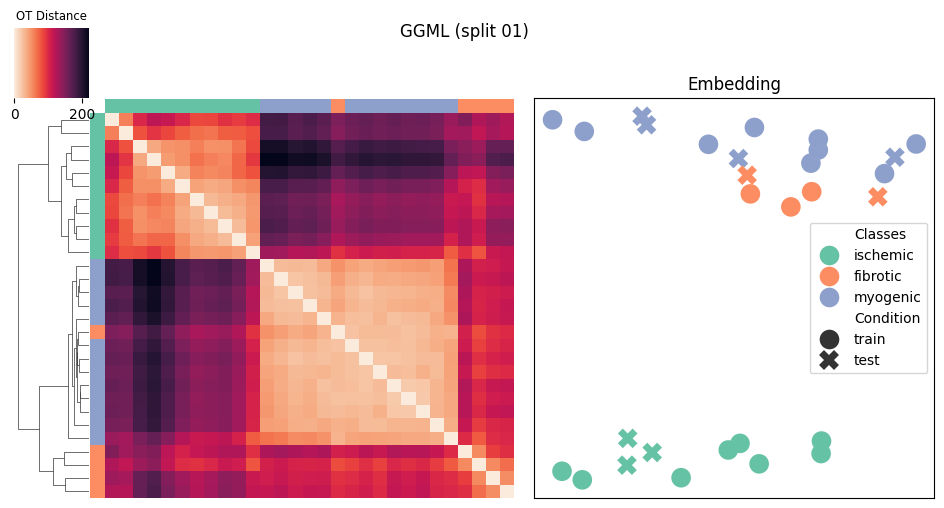

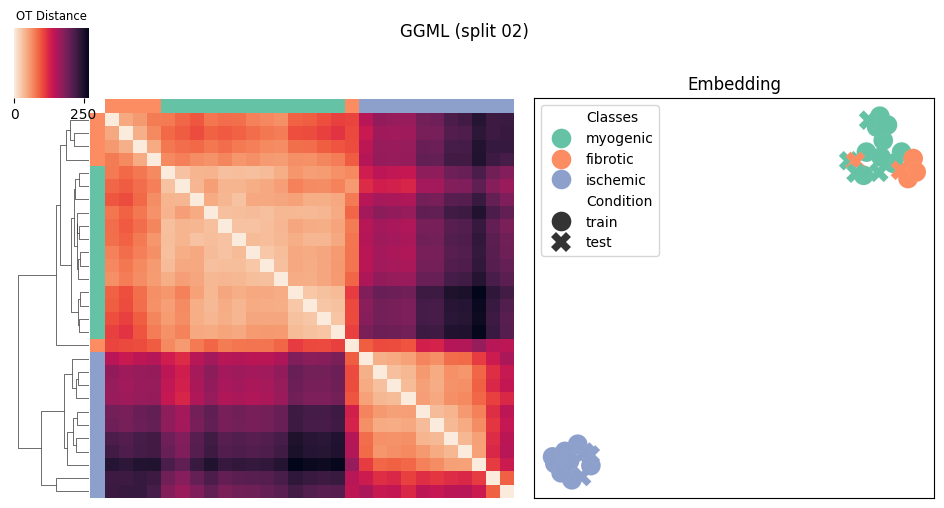

In [12]:
map_As, scores = dataset.train_test(train_size=0.7, test_size=0.3, n_splits=3)